In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/SuperMarket Analysis.csv')

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

In [4]:
branch_metrics = df.groupby('Branch')[['Sales', 'gross income']].sum()
category_metrics = df.groupby('Product line')[['Sales', 'gross income', 'Quantity']].sum()

In [5]:
top_products = category_metrics.sort_values(by='Sales', ascending=False)

In [6]:
df['Month'] = df['Date'].dt.to_period('M').astype(str)
monthly_trend = df.groupby('Month')['Sales'].sum()
daily_trend = df.groupby('Date')['Sales'].sum()

In [7]:

plt.figure(figsize=(16, 10))

<Figure size 1600x1000 with 0 Axes>

<Figure size 1600x1000 with 0 Axes>

C:\Users\Testing\AppData\Local\Temp\ipykernel_18280\42604838.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=branch_metrics.index, y='Sales', data=branch_metrics, palette='viridis')


Text(0.5, 1.0, 'Total Sales by Branch')

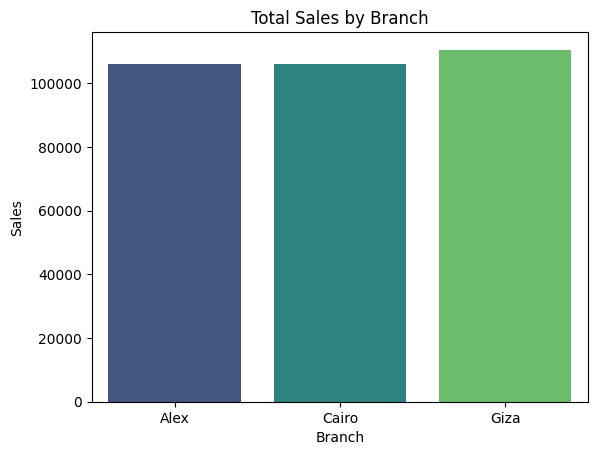

In [8]:
plt.subplot(1,1,1)
sns.barplot(x=branch_metrics.index, y='Sales', data=branch_metrics, palette='viridis')
plt.title('Total Sales by Branch')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Food and beverages'),
  Text(1, 0, 'Sports and travel'),
  Text(2, 0, 'Electronic accessories'),
  Text(3, 0, 'Fashion accessories'),
  Text(4, 0, 'Home and lifestyle'),
  Text(5, 0, 'Health and beauty')])

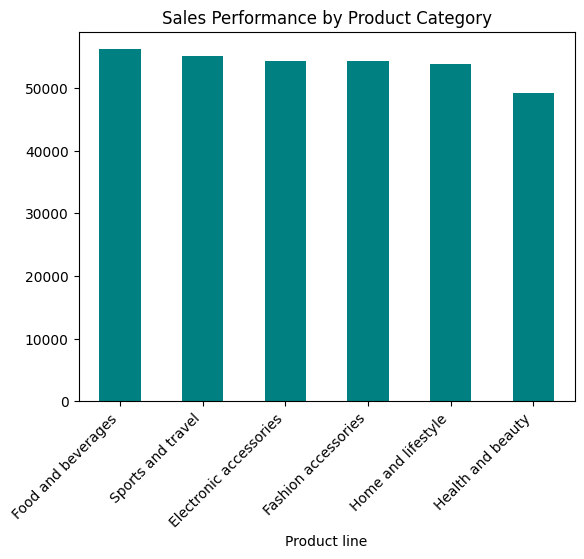

In [9]:
plt.subplot(1,1,1)
top_products['Sales'].plot(kind='bar', color='teal')
plt.title('Sales Performance by Product Category')
plt.xticks(rotation=45, ha='right')

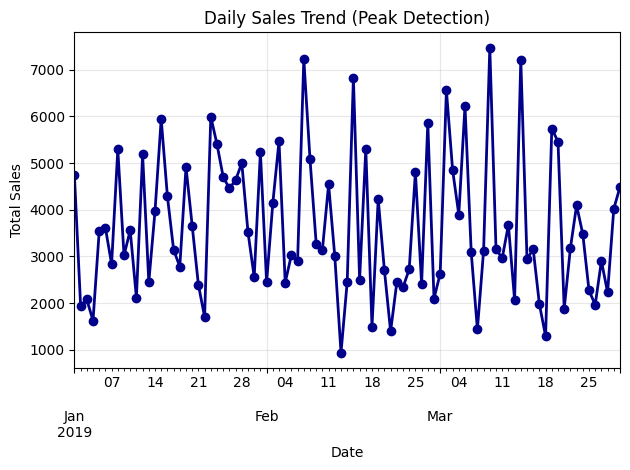

In [10]:
plt.subplot(1,1,1)
daily_trend.plot(kind='line', marker='o', color='darkblue', linewidth=2)
plt.title('Daily Sales Trend (Peak Detection)')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
print("--- BRANCH PERFORMANCE ---")
print(branch_metrics)
print("\n--- TOP 3 BEST-SELLING CATEGORIES ---")
print(top_products.head(3))
print("\n--- UNDERPERFORMING CATEGORIES ---")
print(top_products.tail(2))

--- BRANCH PERFORMANCE ---
              Sales  gross income
Branch                           
Alex    106200.3705     5057.1605
Cairo   106197.6720     5057.0320
Giza    110568.7065     5265.1765

--- TOP 3 BEST-SELLING CATEGORIES ---
                             Sales  gross income  Quantity
Product line                                              
Food and beverages      56144.8440     2673.5640       952
Sports and travel       55122.8265     2624.8965       920
Electronic accessories  54337.5315     2587.5015       971

--- UNDERPERFORMING CATEGORIES ---
                        Sales  gross income  Quantity
Product line                                         
Home and lifestyle  53861.913      2564.853       911
Health and beauty   49193.739      2342.559       854
